In [38]:
# ==================================================
# Configuració del projecte
# ==================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [40]:
# ==================================================
# Imports
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_PROCESSED,
    FIGURES_DIR,
    TABLES_DIR,
)

from src.utils_io import (
    load_csv,
)

In [42]:
# ==================================================
# Carregar dataset mestre
# ==================================================

df = load_csv(
    DATA_PROCESSED / "master.csv"
)

print(df.shape)

display(df.head())

(1898, 19)


,any,tipus_de_territori,territori,renda,preu_lloguer,poblacio_total,Espanya,No consta,Resta de la Unió Europea,Resta del món,Educació primària o inferior,Educació superior,Primera etapa d’educació secundària i similar,Segona etapa d’educació secundària i similar,atur,num_contractes,superficie_mitja,hut,territori_id
0,2000,Barri,baro de viver,NaN,NaN,2368,2351.0,0.0,0.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2001,Barri,baro de viver,NaN,NaN,2373,2354.0,0.0,0.0,18.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,2002,Barri,baro de viver,NaN,NaN,2393,2363.0,0.0,0.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2003,Barri,baro de viver,NaN,NaN,2382,2334.0,0.0,6.0,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2004,Barri,baro de viver,NaN,NaN,2365,2301.0,0.0,0.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [44]:
# ==================================================
# Informació general
# ==================================================

print("\nShape del dataset:")

print(df.shape)

print("\nInformació general:")

df.info()

print("\nPrimeres files:")

display(df.head())


Shape del dataset:
(1898, 19)

Informació general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 19 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   any                                            1898 non-null   int64  
 1   tipus_de_territori                             1898 non-null   object 
 2   territori                                      1898 non-null   object 
 3   renda                                          511 non-null    float64
 4   preu_lloguer                                   866 non-null    float64
 5   poblacio_total                                 1898 non-null   int64  
 6   Espanya                                        1898 non-null   float64
 7   No consta                                      1846 non-null   float64
 8   Resta de la Unió Europea                       1898 non-null   float64
 9   

,any,tipus_de_territori,territori,renda,preu_lloguer,poblacio_total,Espanya,No consta,Resta de la Unió Europea,Resta del món,Educació primària o inferior,Educació superior,Primera etapa d’educació secundària i similar,Segona etapa d’educació secundària i similar,atur,num_contractes,superficie_mitja,hut,territori_id
0,2000,Barri,baro de viver,NaN,NaN,2368,2351.0,0.0,0.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2001,Barri,baro de viver,NaN,NaN,2373,2354.0,0.0,0.0,18.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,2002,Barri,baro de viver,NaN,NaN,2393,2363.0,0.0,0.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2003,Barri,baro de viver,NaN,NaN,2382,2334.0,0.0,6.0,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2004,Barri,baro de viver,NaN,NaN,2365,2301.0,0.0,0.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [46]:
# ==================================================
# Validació territorial
# ==================================================

print("\nNombre de barris:")

print(
    df["territori"].nunique()
)

print("\nAnys disponibles:")

print(
    sorted(df["any"].unique())
)

print("\nDuplicats territorials:")

duplicates = (
    df.groupby("territori")["territori_id"]
    .nunique()
    .sort_values(ascending=False)
)

display(duplicates.head())


Nombre de barris:
73

Anys disponibles:
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Duplicats territorials:


territori
baro de viver      1
la prosperitat     1
navas              1
montbau            1
les tres torres    1
Name: territori_id, dtype: int64

In [48]:
# ==================================================
# Missing values
# ==================================================

print("\nPercentatge de valors nuls:")

missing = (
    df
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

display(
    missing.round(2)
)


Percentatge de valors nuls:


Primera etapa d’educació secundària i similar    80.77
Segona etapa d’educació secundària i similar     80.77
Educació primària o inferior                     80.77
Educació superior                                80.77
renda                                            73.08
hut                                              62.91
preu_lloguer                                     54.37
superficie_mitja                                 53.90
num_contractes                                   53.85
atur                                             42.31
No consta                                         2.74
any                                               0.00
Resta del món                                     0.00
tipus_de_territori                                0.00
Resta de la Unió Europea                          0.00
Espanya                                           0.00
poblacio_total                                    0.00
territori                                         0.00
territori_

In [50]:
# ==================================================
# Variables principals
# ==================================================

eda_vars = [

    "renda",
    "preu_lloguer",
    "poblacio_total",
    "atur",
    "Educació superior",
    "num_contractes",
    "superficie_mitja",
    "hut",

]

In [52]:
# ==================================================
# Estadística descriptiva
# ==================================================

print("\nEstadístiques descriptives:")

desc = (
    df[eda_vars]
    .describe()
    .T
)

desc = desc[
    ["mean", "std", "min", "50%", "max"]
]

desc.columns = [

    "Mitjana",
    "Desv. estàndard",
    "Mínim",
    "Mediana",
    "Màxim",

]

display(
    desc.round(2)
)


Estadístiques descriptives:


,Mitjana,Desv. estàndard,Mínim,Mediana,Màxim
renda,94.71,29.46,47.51,90.89,195.12
preu_lloguer,128.34,29.88,35.00,128.00,227.00
poblacio_total,22145.57,14459.20,439.00,21253.00,59221.00
atur,3420.51,2777.55,10.00,2147.00,9980.00
Educació superior,5595.16,7369.79,0.00,2330.00,30992.00
num_contractes,3150.12,2472.41,11.00,2410.00,9910.00
superficie_mitja,70.58,12.59,38.20,68.30,129.60
hut,364.65,975.59,1.00,50.00,8170.00


In [54]:
# ==================================================
# Exportació taula descriptiva
# ==================================================

latex_table = desc.round(2).to_latex(
    caption=(
        "Estadístiques descriptives "
        "de les variables principals."
    ),
    label="tab:estadistiques_descriptives",
    column_format="lccccc",
)

with open(
    TABLES_DIR / "estadistiques_descriptives.tex",
    "w",
    encoding="utf-8",
) as f:

    f.write(latex_table)

print(
    "Taula descriptiva exportada."
)

Taula descriptiva exportada.


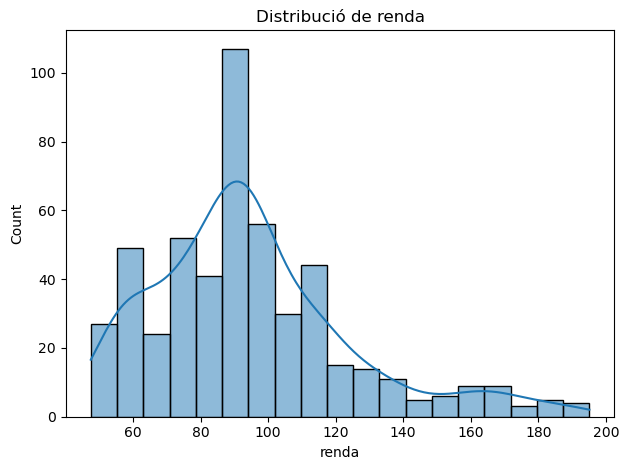

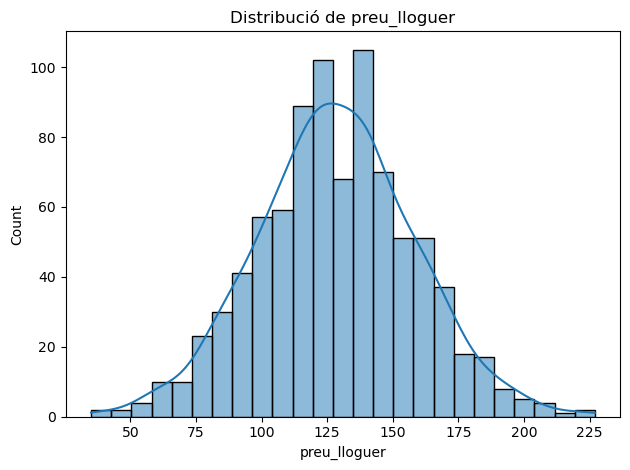

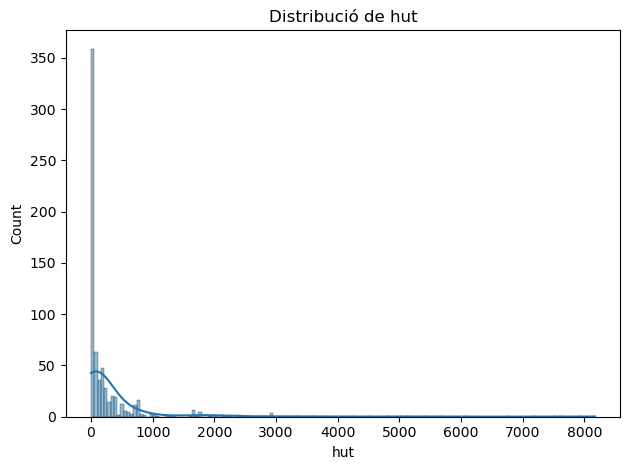

In [56]:
# ==================================================
# Distribucions principals
# ==================================================

distribution_vars = [

    "renda",
    "preu_lloguer",
    "hut",

]

for var in distribution_vars:

    plt.figure()

    sns.histplot(
        df[var],
        kde=True,
    )

    plt.title(
        f"Distribució de {var}"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"dist_{var}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

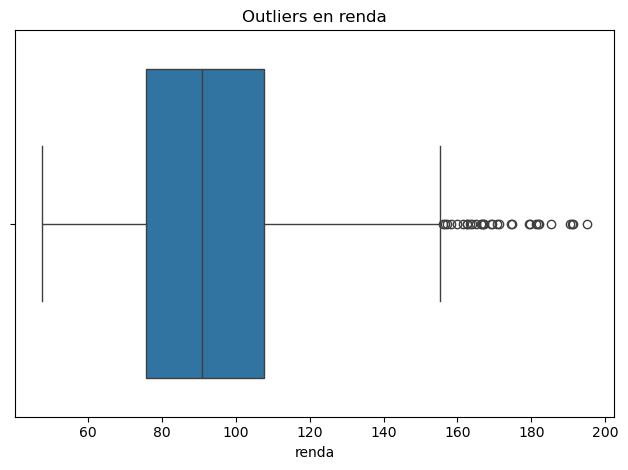

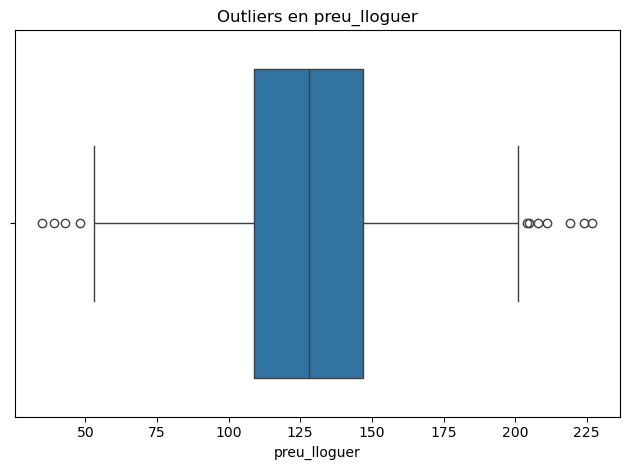

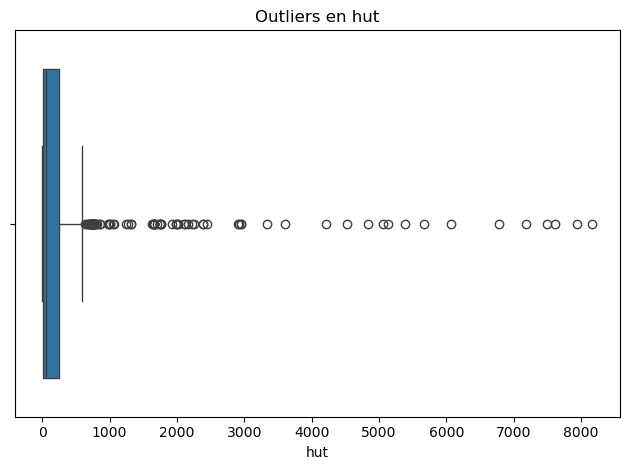

In [57]:
# ==================================================
# Outliers
# ==================================================

for var in distribution_vars:

    plt.figure()

    sns.boxplot(
        x=df[var]
    )

    plt.title(
        f"Outliers en {var}"
    )

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"boxplot_{var}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

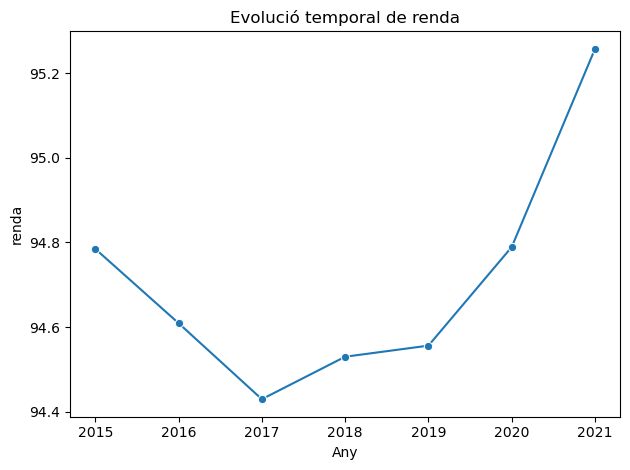

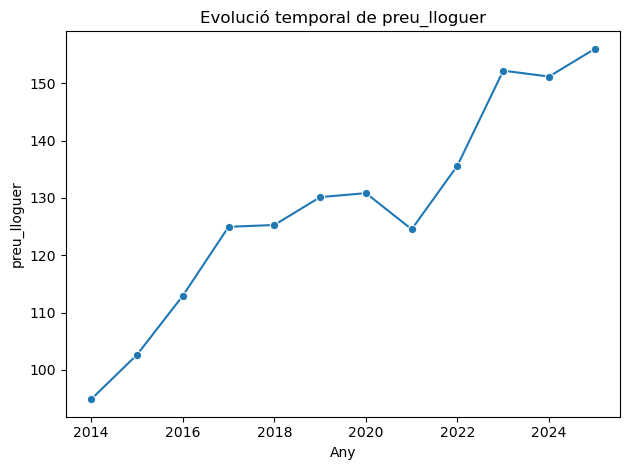

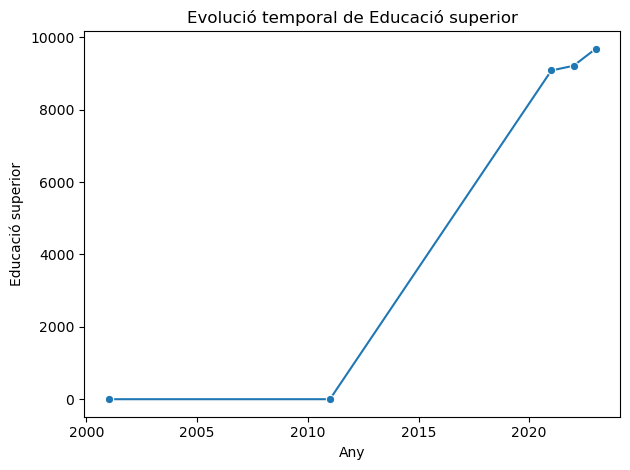

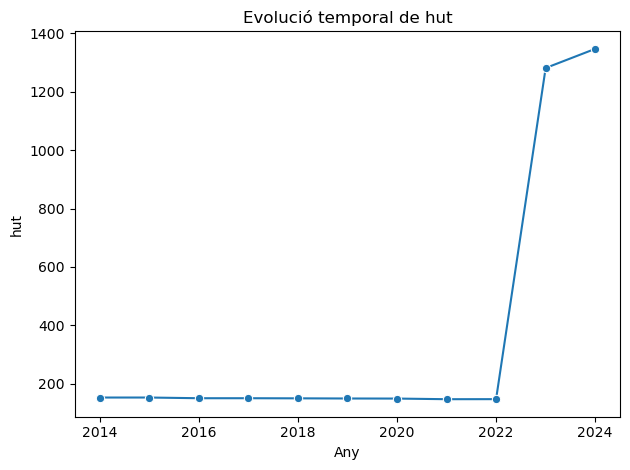

In [58]:
# ==================================================
# Evolució temporal
# ==================================================

df_city = (
    df.groupby("any")[
        [
            "renda",
            "preu_lloguer",
            "Educació superior",
            "hut",
        ]
    ]
    .mean()
    .reset_index()
)

for var in [

    "renda",
    "preu_lloguer",
    "Educació superior",
    "hut",

]:

    plt.figure()

    sns.lineplot(
        data=df_city,
        x="any",
        y=var,
        marker="o",
    )

    plt.title(
        f"Evolució temporal de {var}"
    )

    plt.xlabel("Any")

    plt.ylabel(var)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"evolucio_{var}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

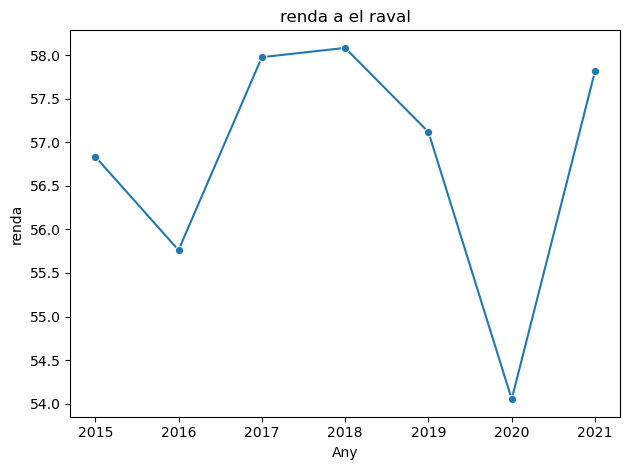

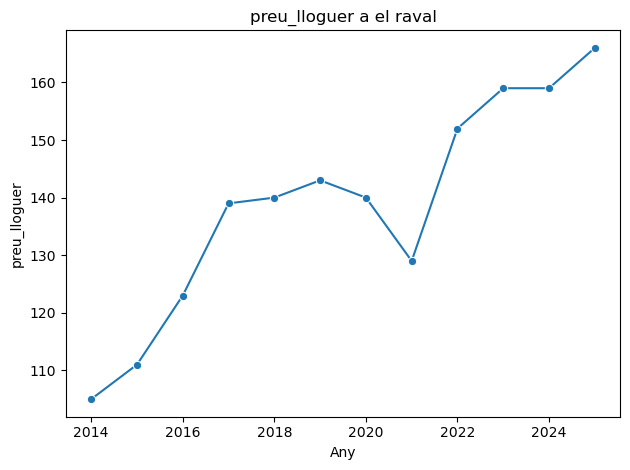

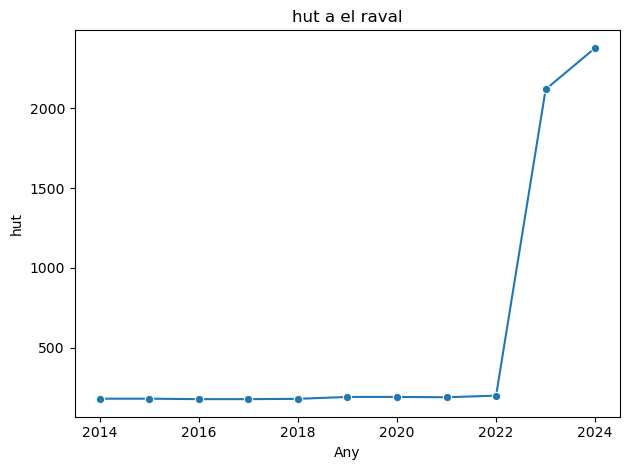

In [59]:
# ==================================================
# Exemple d'evolució d'un barri
# ==================================================

barri = "el raval"

df_barri = df[
    df["territori"] == barri
]

barri_vars = [

    "renda",
    "preu_lloguer",
    "hut",

]

for var in barri_vars:

    plt.figure()

    sns.lineplot(
        data=df_barri,
        x="any",
        y=var,
        marker="o",
    )

    plt.title(
        f"{var} a {barri}"
    )

    plt.xlabel("Any")

    plt.ylabel(var)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"{barri}_{var}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

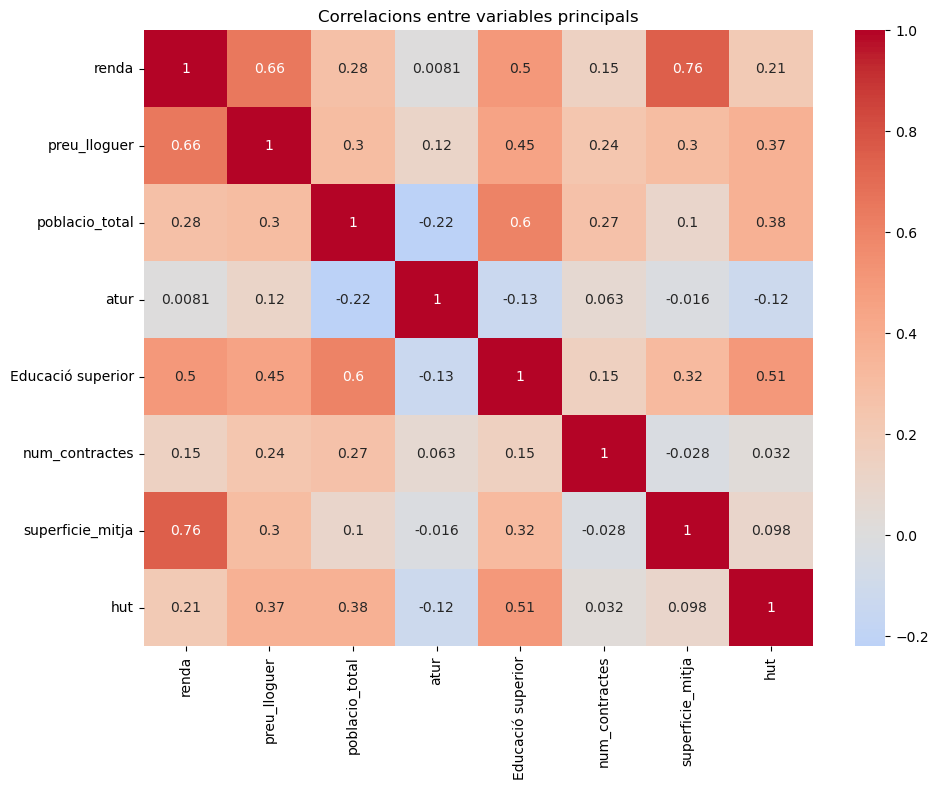

In [60]:
# ==================================================
# Correlacions
# ==================================================

corr_vars = [

    "renda",
    "preu_lloguer",
    "poblacio_total",
    "atur",
    "Educació superior",
    "num_contractes",
    "superficie_mitja",
    "hut",

]

corr = (
    df[corr_vars]
    .corr()
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
)

plt.title(
    "Correlacions entre variables principals"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlacions_principals.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [62]:
# ==================================================
# Correlacions més elevades
# ==================================================

corr_pairs = (
    corr.unstack()
    .sort_values(
        key=abs,
        ascending=False,
    )
)

corr_pairs = corr_pairs[
    corr_pairs < 0.999
]

print(
    "\nCorrelacions més elevades:"
)

display(
    corr_pairs.head(10)
)


Correlacions més elevades:


renda              superficie_mitja     0.756902
superficie_mitja   renda                0.756902
preu_lloguer       renda                0.656583
renda              preu_lloguer         0.656583
Educació superior  poblacio_total       0.600334
poblacio_total     Educació superior    0.600334
hut                Educació superior    0.506613
Educació superior  hut                  0.506613
renda              Educació superior    0.504685
Educació superior  renda                0.504685
dtype: float64